2025-04-13 13:38:43.727766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744551524.020510      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744551524.092821      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


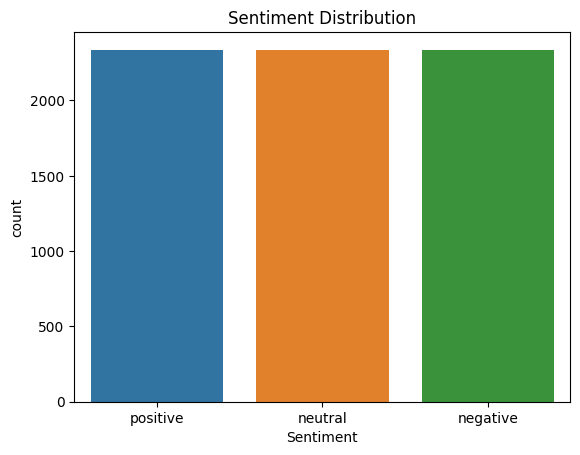

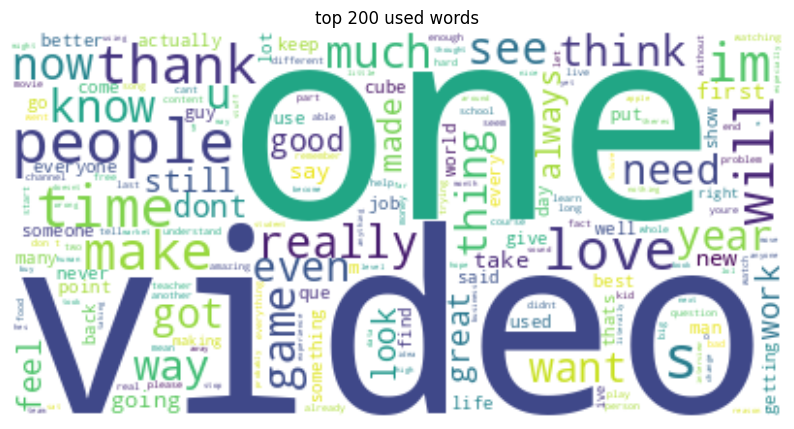

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Training loss: 0.4898 | Accuracy: 0.8099

Epoch 3/4


Epoch 3 Progress:   0%|          | 0/176 [00:00<?, ?it/s]

Training loss: 0.3320 | Accuracy: 0.8807

Epoch 4/4


Epoch 4 Progress:   0%|          | 0/176 [00:00<?, ?it/s]

Training loss: 0.2159 | Accuracy: 0.9276


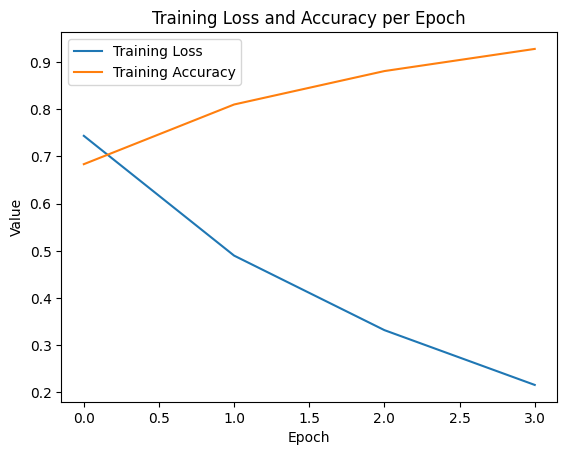

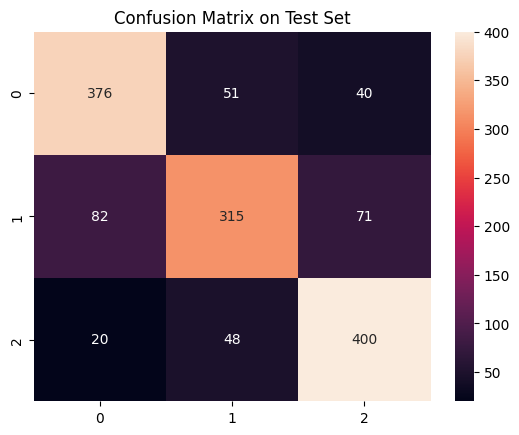

In [1]:
# ✅ Hugging Face BERT Fine-Tuning for Sentiment Analysis (Cleaned Version + Visualizations Restored)

# Imports
import os
import re
import string
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from tqdm.notebook import tqdm

# Read data
data = pd.read_csv("/kaggle/input/youtubecomments/YoutubeCommentsDataSet.csv")
data.dropna(inplace=True)

# Balance dataset
random_state = 42
n = data['Sentiment'].value_counts().min()
pos_data = data[data['Sentiment']=='positive'].sample(n=n, random_state=random_state)
neu_data = data[data['Sentiment']=='neutral'].sample(n=n, random_state=random_state)
neg_data = data[data['Sentiment']=='negative'].sample(n=n, random_state=random_state)
final_data = pd.concat([pos_data, neu_data, neg_data]).reset_index(drop=True)

# Visualization: Sentiment distribution
sns.countplot(x=final_data['Sentiment'])
plt.title("Sentiment Distribution")
plt.show()

# Visualization: WordCloud of comments
sent_list = final_data['Comment'].tolist()
wc  = WordCloud(background_color='white', max_words=200, random_state=random_state, stopwords=STOPWORDS)
wc.generate(" ".join(sent_list))
plt.figure(figsize=(10,6))
plt.imshow(wc, interpolation='bilinear')
plt.title("top 200 used words")
plt.axis('off')
plt.show()

# Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

word_dict = {"im": "i am", "u": "you", "cant": "can not", "can't": "can not", "youre": "you are", "you're": "you are", "ive": "i have", "i've": "i have"}
STOPWORDS = set(stopwords.words('english'))
STOPWORDS.discard('not')
lemmatizer = WordNetLemmatizer()

def preprocessing(text):
    text = text.lower()
    clean_text = re.sub("\'t", " not", text)
    clean_text = re.sub("\'re", " are", clean_text)
    clean_text = re.sub("\'m", " am", clean_text)
    clean_text = re.sub("[^A-Za-z0-9]", " ", clean_text)
    clean_text = re.sub("\s+", " ", clean_text).strip()
    words = clean_text.split(" ")
    words = [word_dict.get(word, word) for word in words]
    clean_words = [word for word in words if word not in STOPWORDS]
    return " ".join(clean_words)

final_data['clean_text'] = final_data['Comment'].apply(preprocessing)

# Tokenization
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 512
BATCH_SIZE = 32
EPOCHS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X = final_data['clean_text'].values
y = final_data['Sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

num_labels = len(np.unique(y_train))

# Save encoder
import pickle
with open("/kaggle/working/label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.save_pretrained("sentiment_model")

def tokenize_data(data):
    input_ids, attention_masks = [], []
    for text in data:
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt')
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
    return torch.cat(input_ids), torch.cat(attention_masks)

train_input_ids, train_attention_mask = tokenize_data(X_train)
test_input_ids, test_attention_mask = tokenize_data(X_test)

y_train_tensor = torch.tensor(y_train)
y_test_tensor = torch.tensor(y_test)

# Dataset
class CustomDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx].to(device),
            'attention_mask': self.attention_mask[idx].to(device),
            'labels': self.labels[idx].to(device)
        }

train_dataset = CustomDataset(train_input_ids, train_attention_mask, y_train_tensor)
test_dataset = CustomDataset(test_input_ids, test_attention_mask, y_test_tensor)

train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=BATCH_SIZE)

# Model
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
model.to(device)

# Training
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(device))

model.train()
train_losses = []
train_accuracies = []
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Progress"):
        b_input_ids = batch['input_ids'].to(device)
        b_attention_mask = batch['attention_mask'].to(device)
        b_labels = batch['labels'].to(device)

        model.zero_grad()
        output = model(b_input_ids, attention_mask=b_attention_mask)
        loss = loss_fn(output.logits, b_labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(output.logits, dim=1)
        correct += (preds == b_labels).sum().item()
        total += b_labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f"Training loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

plt.plot(train_losses, label='Training Loss')
plt.plot(train_accuracies, label='Training Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss and Accuracy per Epoch")
plt.legend()
plt.show()

# Save the model
model.save_pretrained("/kaggle/working/sentiment_model")
tokenizer.save_pretrained("/kaggle/working/sentiment_model")

# Evaluation
model.eval()
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        b_input_ids = batch['input_ids'].to(device)
        b_attention_mask = batch['attention_mask'].to(device)
        output = model(b_input_ids, attention_mask=b_attention_mask)
        preds = torch.argmax(output.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

sns.heatmap(confusion_matrix(y_test, all_preds), annot=True, fmt='d')
plt.title("Confusion Matrix on Test Set")
plt.show()
